# **Data Processing**

In [1]:
# ==========================================
# SETUP AND STRICT SPLITTING
# ==========================================

import os
import shutil
import random
import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import kagglehub
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import time
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

# Set seeds for reproducibility
random.seed(42)
torch.manual_seed(42)

# 1. Download Dataset
print("Downloading GTZAN Dataset...")
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")
source_dir = os.path.join(path, 'Data', 'genres_original')
target_root = 'gtzan_audio_split'

# 2. Strict File-Level Split (80/10/10)
if not os.path.exists(target_root):
    print("Building strict isolated directories to prevent data leakage...")
    genres = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]

    for split in ['train', 'val', 'test']:
        for genre in genres:
            os.makedirs(os.path.join(target_root, split, genre), exist_ok=True)

    for genre in genres:
        genre_path = os.path.join(source_dir, genre)
        files = [f for f in os.listdir(genre_path) if f.endswith('.wav')]

        # Remove known corrupted file
        if 'jazz.00054.wav' in files: files.remove('jazz.00054.wav')

        random.shuffle(files)
        train_idx, val_idx = int(len(files) * 0.8), int(len(files) * 0.9)

        splits = {
            'train': files[:train_idx],
            'val': files[train_idx:val_idx],
            'test': files[val_idx:]
        }

        for split, split_files in splits.items():
            for f in split_files:
                shutil.copy(os.path.join(genre_path, f), os.path.join(target_root, split, genre, f))
    print("Data successfully downloaded and split!")
else:
    print("Split directories already exist. Skipping split phase.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Device: {device}")

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Building strict isolated directories to prevent data leakage...
Data successfully downloaded and split!
Active Device: cuda


In [3]:
# ==========================================
# DATA PROCESSING & LOADERS
# ==========================================

class GTZAN_3Second_Dataset(Dataset):
    def __init__(self, root_dir, split, sample_rate=22050, duration=3, augment=False):
        self.root_dir = os.path.join(root_dir, split)
        self.sample_rate = sample_rate
        self.n_samples = sample_rate * duration
        self.augment = augment
        self.file_list = []

        genres = sorted(os.listdir(self.root_dir))
        self.label_to_idx = {genre: i for i, genre in enumerate(genres)}

        for genre in genres:
            genre_dir = os.path.join(self.root_dir, genre)
            for f in os.listdir(genre_dir):
                if f.endswith('.wav'):
                    full_path = os.path.join(genre_dir, f)
                    for segment_idx in range(10):
                        self.file_list.append((full_path, self.label_to_idx[genre], segment_idx))

        self.mel_spectrogram = torchaudio.transforms.MelSpectrogram(
            sample_rate=self.sample_rate, n_fft=2048, hop_length=512, n_mels=128
        )
        self.amplitude_to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)
        self.pitch_shift = torchaudio.transforms.PitchShift(sample_rate, n_steps=2)

    def add_white_noise(self, waveform, noise_level=0.005):
        return waveform + (torch.randn_like(waveform) * noise_level)

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        path, label, segment_idx = self.file_list[idx]
        offset = segment_idx * self.n_samples

        try:
            waveform, sr = torchaudio.load(path, frame_offset=offset, num_frames=self.n_samples)
            if waveform.numel() == 0 or waveform.shape[1] == 0:
                waveform, sr = torch.zeros((1, self.n_samples)), self.sample_rate
        except Exception:
            waveform, sr = torch.zeros((1, self.n_samples)), self.sample_rate

        if sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(orig_freq=sr, new_freq=self.sample_rate)(waveform)
        if waveform.shape[0] > 1:
            waveform = torch.mean(waveform, dim=0, keepdim=True)

        # 1. Augmentations FIRST
        if self.augment:
            if random.random() > 0.5: waveform = self.pitch_shift(waveform)
            if random.random() > 0.5: waveform = self.add_white_noise(waveform)

        # 2. Spectrogram Conversion
        mel_spec = self.mel_spectrogram(waveform)
        mel_spec_db = self.amplitude_to_db(mel_spec)

        # 3. Strict Padding/Truncating to guarantee 130 frames
        target_frames = 130
        if mel_spec_db.shape[2] < target_frames:
            mel_spec_db = F.pad(mel_spec_db, (0, target_frames - mel_spec_db.shape[2]))
        else:
            mel_spec_db = mel_spec_db[:, :, :target_frames]

        return mel_spec_db, torch.tensor(label)

# Initialize DataLoaders
batch_size = 32
train_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'train', augment=True), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'val', augment=False), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(GTZAN_3Second_Dataset('gtzan_audio_split', 'test', augment=False), batch_size=batch_size, shuffle=False)

# Print the exact size of the final datasets (in 3-second slices)
print(f"Total Training Samples: {len(train_loader.dataset)}")
print(f"Total Validation Samples: {len(val_loader.dataset)}")
print(f"Total Test Samples: {len(test_loader.dataset)}")

Total Training Samples: 7990
Total Validation Samples: 1000
Total Test Samples: 1000


# **Model Architecture**

The "Ultimate Ensemble" is a soft-voting fusion model designed to combine two fundamentally different deep learning paradigms: a custom Multi-Scale Spectrogram CNN (the "Rhythm Expert") and a fine-tuned ResNet-50 (the "Texture Expert"). The custom CNN utilizes parallel asymmetric convolutional kernels (1x7 and 7x1) paired with Squeeze-and-Excitation attention to explicitly capture temporal drum beats and harmonic pitch structures. Conversely, the ResNet-50 leverages deep, ImageNet-pretrained 3x3 convolutions to identify dense, complex acoustic textures. During inference, both models independently evaluate the same 3-second Mel Spectrogram slice and output class logits. These logits are converted into probability distributions via a softmax function and mathematically averaged. This allows the ensemble to make a final prediction that balances rhythmic sensitivity with sophisticated textural pattern recognition.

In [6]:
# ==========================================
# MODEL ARCHITECTURES
# ==========================================

# --- 1. THE RHYTHM EXPERT (Custom Multi-Scale CNN) ---
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.squeeze = nn.AdaptiveAvgPool2d(1)
        self.excitation = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.excitation(self.squeeze(x).view(b, c)).view(b, c, 1, 1)
        return x * y.expand_as(x)

class MultiScaleSpectroBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiScaleSpectroBlock, self).__init__()
        self.conv_std = nn.Conv2d(in_channels, out_channels // 3, kernel_size=3, padding='same')
        self.conv_tmp = nn.Conv2d(in_channels, out_channels // 3, kernel_size=(1, 7), padding='same')
        self.conv_frq = nn.Conv2d(in_channels, out_channels - 2*(out_channels // 3), kernel_size=(7, 1), padding='same')
        self.bn = nn.BatchNorm2d(out_channels)
        self.se = SEBlock(out_channels)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        out = torch.cat([self.conv_std(x), self.conv_tmp(x), self.conv_frq(x)], dim=1)
        return self.pool(self.se(F.leaky_relu(self.bn(out), 0.01)))

class SpectroCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectroCNN, self).__init__()
        self.init_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(32), nn.LeakyReLU(0.01)
        )
        self.blocks = nn.Sequential(
            MultiScaleSpectroBlock(32, 64),
            MultiScaleSpectroBlock(64, 128),
            MultiScaleSpectroBlock(128, 256),
            MultiScaleSpectroBlock(256, 512)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(512, 256), nn.BatchNorm1d(256), nn.LeakyReLU(0.01),
            nn.Dropout(0.5), nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.pool(self.blocks(self.init_conv(x))).view(x.size(0), -1)
        return self.classifier(x)

# --- 2. THE TEXTURE EXPERT (ResNet-50 Transfer Learning) ---
class SpectroResNet50(nn.Module):
    def __init__(self, num_classes=10):
        super(SpectroResNet50, self).__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        # Collapse RGB to Grayscale safely
        orig_weight = self.resnet.conv1.weight.clone()
        self.resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            self.resnet.conv1.weight = nn.Parameter(torch.sum(orig_weight, dim=1, keepdim=True))
        # Custom head
        num_ftrs = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(num_ftrs, num_classes))
    def forward(self, x):
        return self.resnet(x)

# --- 3. THE ULTIMATE ENSEMBLE ---
class UltimateEnsemble(nn.Module):
    def __init__(self, model_a, model_b):
        super(UltimateEnsemble, self).__init__()
        self.model_a = model_a
        self.model_b = model_b
    def forward(self, x):
        prob_a = F.softmax(self.model_a(x), dim=1)
        prob_b = F.softmax(self.model_b(x), dim=1)
        return (prob_a + prob_b) / 2.0

In [7]:
# ==========================================
# TRAINING LOOP
# ==========================================

def train_model(model, model_name, epochs, lr, train_loader, val_loader, device):
    print(f"\n{'='*50}\n STARTING TRAINING: {model_name}\n{'='*50}")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            msg = "--> Best Model Saved!"
        else:
            msg = ""

        print(f"Epoch [{epoch+1:02d}/{epochs}] | Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.2f}% {msg}")

    print(f"\n[{model_name}] Training Completed in {(time.time() - start_time) / 60:.2f} minutes!")
    print(f"[{model_name}] Absolute Best Validation Accuracy: {best_val_acc:.2f}%")
    return model

# 1. Train Custom CNN
model_cnn = SpectroCNN(num_classes=10).to(device)
train_model(model_cnn, "spectro_cnn", epochs=40, lr=0.001, train_loader=train_loader, val_loader=val_loader, device=device)

# 2. Fine-Tune ResNet-50
model_resnet = SpectroResNet50(num_classes=10).to(device)
train_model(model_resnet, "resnet50", epochs=20, lr=0.0005, train_loader=train_loader, val_loader=val_loader, device=device)


 STARTING TRAINING: spectro_cnn
Epoch [01/40] | Train Loss: 1.2119 | Val Acc: 62.90% --> Best Model Saved!
Epoch [02/40] | Train Loss: 0.7156 | Val Acc: 59.20% 
Epoch [03/40] | Train Loss: 0.5416 | Val Acc: 61.50% 
Epoch [04/40] | Train Loss: 0.4396 | Val Acc: 72.20% --> Best Model Saved!
Epoch [05/40] | Train Loss: 0.3572 | Val Acc: 76.00% --> Best Model Saved!
Epoch [06/40] | Train Loss: 0.2982 | Val Acc: 80.60% --> Best Model Saved!
Epoch [07/40] | Train Loss: 0.2175 | Val Acc: 78.60% 
Epoch [08/40] | Train Loss: 0.1880 | Val Acc: 75.50% 
Epoch [09/40] | Train Loss: 0.1578 | Val Acc: 82.60% --> Best Model Saved!
Epoch [10/40] | Train Loss: 0.1326 | Val Acc: 83.90% --> Best Model Saved!
Epoch [11/40] | Train Loss: 0.1091 | Val Acc: 78.80% 
Epoch [12/40] | Train Loss: 0.1029 | Val Acc: 79.60% 
Epoch [13/40] | Train Loss: 0.0853 | Val Acc: 83.70% 
Epoch [14/40] | Train Loss: 0.0759 | Val Acc: 84.90% --> Best Model Saved!
Epoch [15/40] | Train Loss: 0.0556 | Val Acc: 87.00% --> Best Mo

100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]



 STARTING TRAINING: resnet50
Epoch [01/20] | Train Loss: 1.0003 | Val Acc: 64.00% --> Best Model Saved!
Epoch [02/20] | Train Loss: 0.4709 | Val Acc: 80.80% --> Best Model Saved!
Epoch [03/20] | Train Loss: 0.3017 | Val Acc: 78.60% 
Epoch [04/20] | Train Loss: 0.2113 | Val Acc: 83.90% --> Best Model Saved!
Epoch [05/20] | Train Loss: 0.1605 | Val Acc: 83.40% 
Epoch [06/20] | Train Loss: 0.1131 | Val Acc: 85.20% --> Best Model Saved!
Epoch [07/20] | Train Loss: 0.0888 | Val Acc: 87.80% --> Best Model Saved!
Epoch [08/20] | Train Loss: 0.0620 | Val Acc: 84.60% 
Epoch [09/20] | Train Loss: 0.0515 | Val Acc: 87.10% 
Epoch [10/20] | Train Loss: 0.0370 | Val Acc: 86.90% 
Epoch [11/20] | Train Loss: 0.0234 | Val Acc: 89.00% --> Best Model Saved!
Epoch [12/20] | Train Loss: 0.0133 | Val Acc: 88.90% 
Epoch [13/20] | Train Loss: 0.0138 | Val Acc: 88.20% 
Epoch [14/20] | Train Loss: 0.0072 | Val Acc: 89.40% --> Best Model Saved!
Epoch [15/20] | Train Loss: 0.0063 | Val Acc: 89.90% --> Best Model

SpectroResNet50(
  (resnet): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

Loading optimized weights into the Ensemble...
Running Inference on Isolated Test Set...

 ULTIMATE ENSEMBLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

       blues       0.88      0.92      0.90       100
   classical       0.97      0.99      0.98       100
     country       0.76      0.78      0.77       100
       disco       0.91      0.82      0.86       100
      hiphop       0.86      0.86      0.86       100
        jazz       0.85      0.88      0.86       100
       metal       0.98      0.90      0.94       100
         pop       0.80      0.78      0.79       100
      reggae       0.89      0.73      0.80       100
        rock       0.57      0.73      0.64       100

    accuracy                           0.84      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.85      0.84      0.84      1000



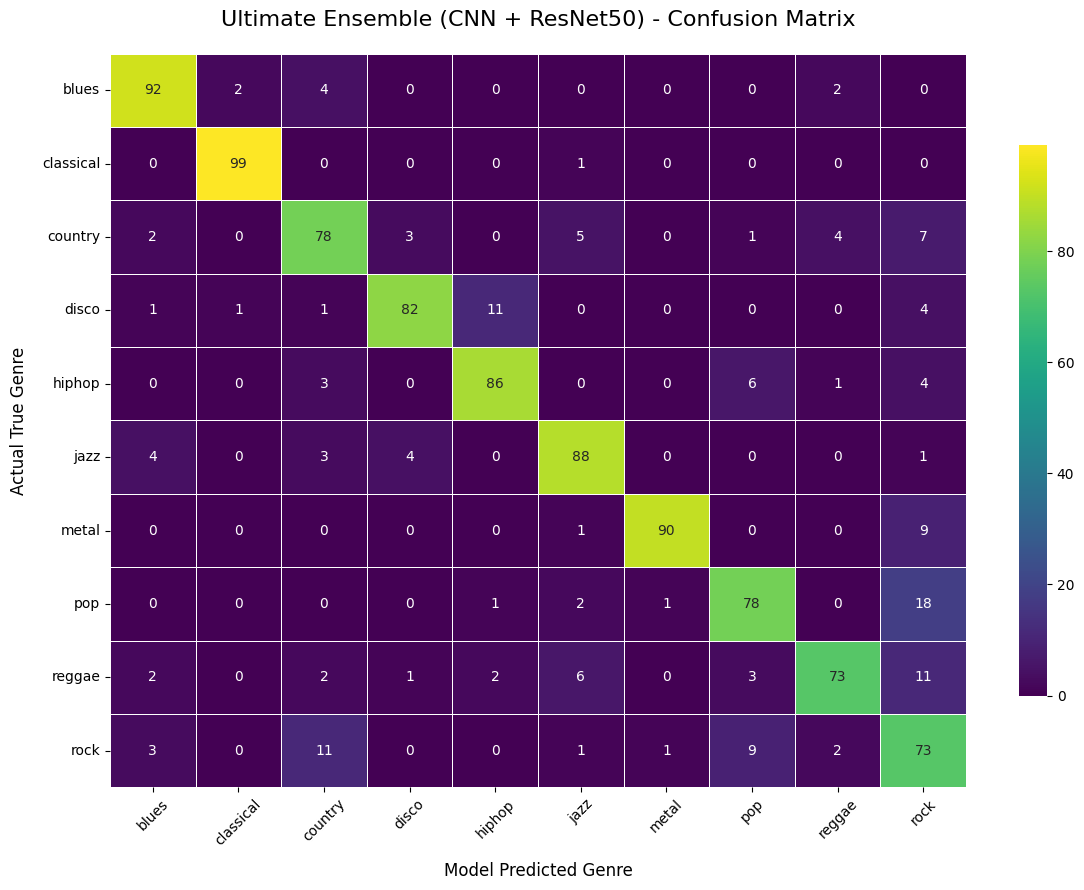

In [8]:
# ==========================================
# EVALUATION
# ==========================================

print("Loading optimized weights into the Ensemble...")
expert_cnn = SpectroCNN(num_classes=10).to(device)
expert_cnn.load_state_dict(torch.load('best_spectro_cnn.pth'))
expert_cnn.eval()

expert_resnet = SpectroResNet50(num_classes=10).to(device)
expert_resnet.load_state_dict(torch.load('best_resnet50.pth'))
expert_resnet.eval()

ultimate_model = UltimateEnsemble(expert_cnn, expert_resnet).to(device)
ultimate_model.eval()

y_true = []
y_pred = []

print("Running Inference on Isolated Test Set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = ultimate_model(inputs)
        _, predicted = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

genres = sorted(os.listdir('gtzan_audio_split/test'))

print("\n" + "="*50)
print(" ULTIMATE ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred, target_names=genres))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=genres, yticklabels=genres,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Ultimate Ensemble (CNN + ResNet50) - Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual True Genre', fontsize=12, labelpad=10)
plt.xlabel('Model Predicted Genre', fontsize=12, labelpad=10)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()